In [17]:
import pandas as pd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
import shap
import pickle

In [18]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [19]:
df.drop('customerID', axis=1,inplace=True)

In [20]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
before = len(df)
df.dropna(inplace=True)
print(f"Dropped {before - len(df)} rows with missing TotalCharges (kept {len(df)})")

Dropped 11 rows with missing TotalCharges (kept 7032)


In [21]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [22]:
df.replace({'No internet service': 'No','No phone service': 'No'}, inplace=True)

In [23]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str)

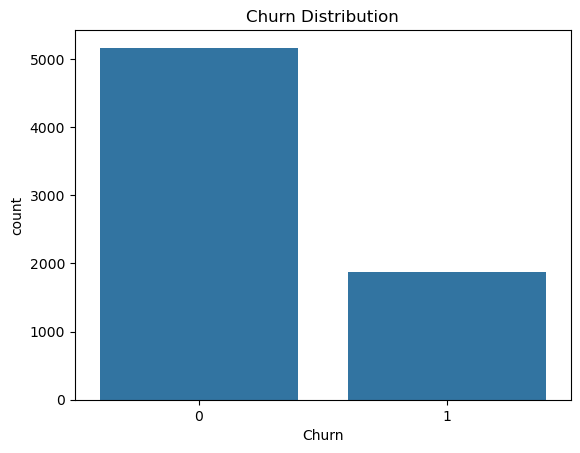

In [24]:
fig, ax = plt.subplots()
sns.countplot(x="Churn", data=df, ax=ax)
ax.set_title("Churn Distribution")
plt.show()

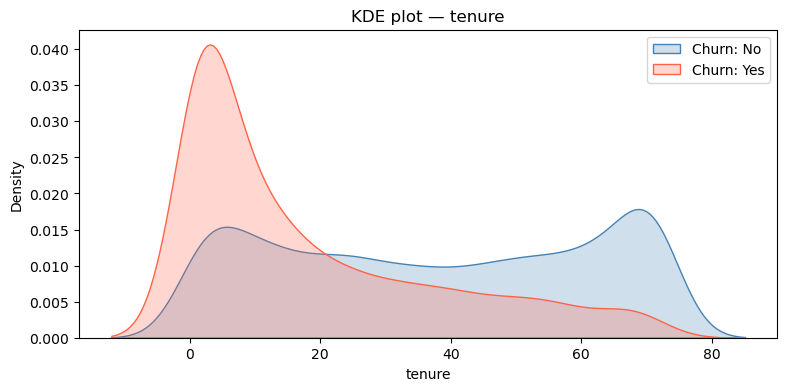

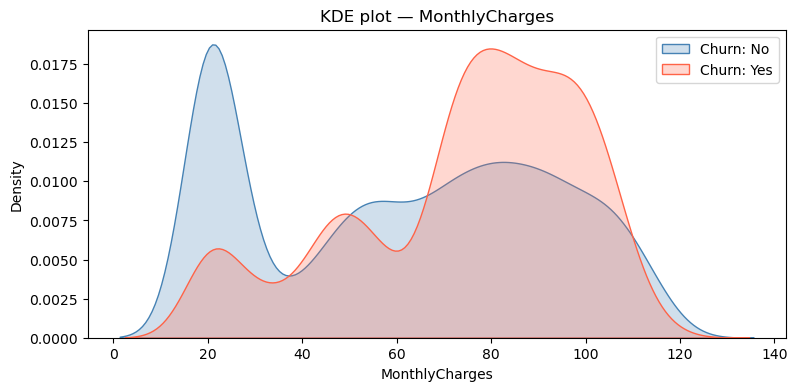

KeyError: 'AvgMonthlySpend'

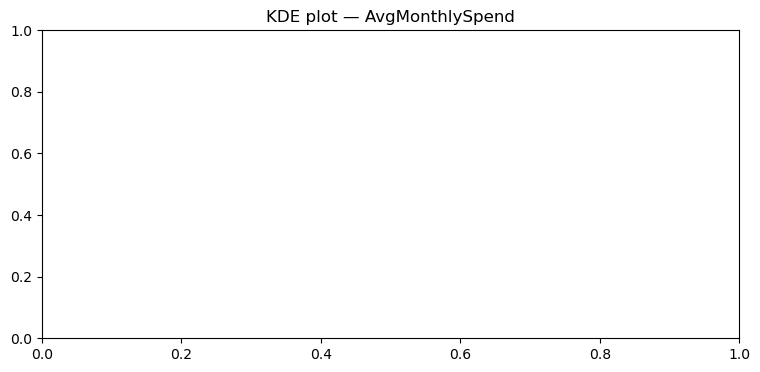

In [26]:
def kdeplot(feature: str, save: bool = True):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.set_title(f"KDE plot — {feature}")
    sns.kdeplot(
        df[df["Churn"] == 0][feature].dropna(),
        color="steelblue",
        label="Churn: No",
        fill=True,
        ax=ax,
    )
    sns.kdeplot(
        df[df["Churn"] == 1][feature].dropna(),
        color="tomato",
        label="Churn: Yes",
        fill=True,
        ax=ax,
    )
    ax.legend()
    plt.show()

kdeplot("tenure")
kdeplot("MonthlyCharges")
kdeplot("AvgMonthlySpend")

In [27]:
x = df.drop('Churn', axis=1)
y = df['Churn']

In [28]:
categorical_cols = x.select_dtypes(include=['object']).columns
numerical_cols = x.select_dtypes(include=['int64','float64']).columns

In [29]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(eval_metric='logloss'))
])

In [30]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtect...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=None, ...))])

In [31]:
y_pred = pipeline.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n",classification_report(y_test, y_pred))

Accuracy: 0.7789623312011372
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.85      1033
           1       0.60      0.51      0.55       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



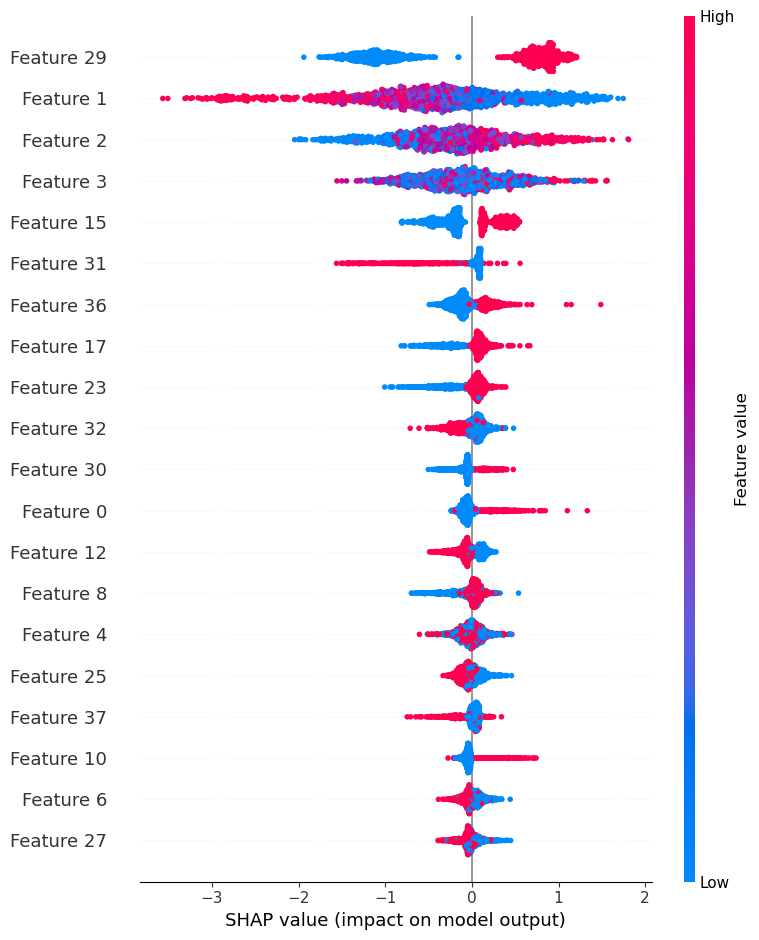

In [32]:
model = pipeline.named_steps["model"]
x_test_transformed = pipeline.named_steps["preprocessor"].transform(x_test)
explainer = shap.Explainer(model)
shap_values = explainer(x_test_transformed)
shap.summary_plot(shap_values, x_test_transformed)

In [33]:
pickle.dump(pipeline,open("model.pkl","wb"))